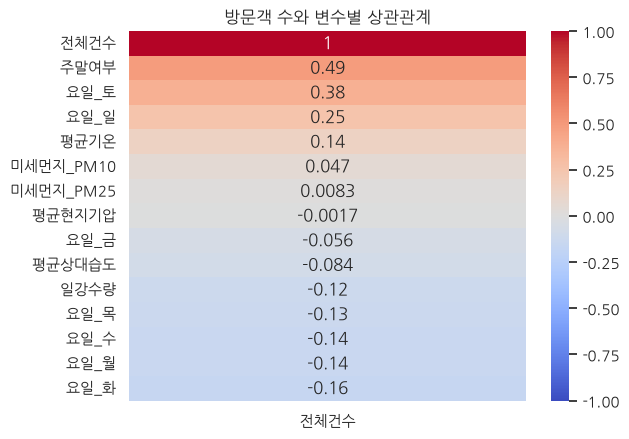

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='NanumGothic') # korean for plt
plt.rc('axes', unicode_minus=False) # prevent minus error
sns.set_theme(font='NanumGothic') # korean for sns

def preprocess(path):
    df = pd.read_csv(path)
    df['일자'] = pd.to_datetime(df['일자'])
    df['요일'] = df['일자'].dt.day_name().map({'Monday':'월','Tuesday':'화','Wednesday':'수','Thursday':'목','Friday':'금','Saturday':'토','Sunday':'일'})
    df['주말여부'] = (df['일자'].dt.weekday >= 5).astype(int)
    df = pd.get_dummies(df, columns=['요일'], prefix='요일', dtype=int)
    cols = ['전체건수','평균기온','일강수량','평균상대습도','평균현지기압','미세먼지_PM10','미세먼지_PM25']
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
    return df[['일자','전체건수','주말여부','평균기온','일강수량','평균상대습도','평균현지기압','미세먼지_PM10','미세먼지_PM25'] + [f'요일_{d}' for d in '월화수목금토일']]

def visualize(df):
    corr = df.drop(columns='일자').corr()[['전체건수']].sort_values('전체건수', ascending=False)
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('방문객 수와 변수별 상관관계')
    plt.show()

if __name__ == '__main__':
    df = preprocess('Oworld.csv')
    visualize(df)

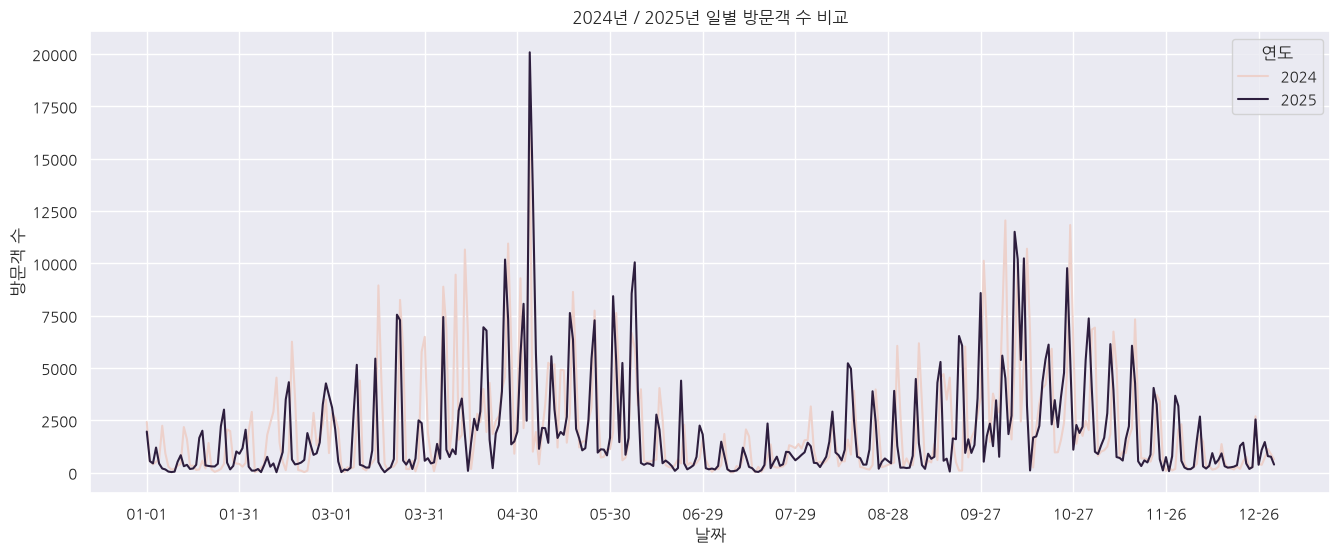

In [ ]:
df['일자'] = pd.to_datetime(df['일자'])
df['연도'] = df['일자'].dt.year
df['월일'] = df['일자'].dt.strftime('%m-%d')

temp = df[df['연도'].isin([2024, 2025])]

plt.figure(figsize=(16, 6))
sns.lineplot(data=temp, x='월일', y='전체건수', hue='연도')
plt.xticks(range(0, 365, 30))
plt.xlabel('날짜')
plt.ylabel('방문객 수')
plt.title('2024년 / 2025년 일별 방문객 수 비교')
plt.show()

대전 인근 문화행사 가져오기

In [4]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

url = 'https://apis.data.go.kr/B554695/CultureScheduleSVC/getCultureSchedule01'

# 사용기간 8/12 하루임
params = {
    'ServiceKey': '2O6qkZfedoF9zCkn3ccvnpsAu4qUsrXxRG8Cws3TjjPBHBLLKrkx17xR+LTQe2DKX5aB4w1nxbyEuwIewFrcOg==',
    'pageNo': '1',
    'numOfRows': '1000',
    '_type': 'json',
    'sdate': 20230101,
    'edate': 20260812,
}

response = requests.get(url, params=params)

if response.status_code == 200:
        data = response.json()
        body = data.get('response', {}).get('body', {})
        total_count = body.get('totalCount', 0)
        print(f"=== 조회된 데이터 수: {total_count}건) ===")

        items_data = body.get('items', {}).get('item', [])
        
        # 데이터가 1건일 경우
        if isinstance(items_data, dict):
            items_data = [items_data]
            
        parsed_items = []
        for item in items_data:
            content = item.get('content', item.get('content', '-'))
            sdate = item.get('sdate', item.get('SDate', '-'))
            edate = item.get('edate', item.get('EDate', '-'))
            place = item.get('place', '-')
            
            print(f"행사명: {content} | 기간: {sdate} ~ {edate} | 장소: {place}")
            
            parsed_items.append({
                'content': content,
                'sdate': sdate,
                'edate': edate,
                'place': place
            })
        
        if parsed_items:
            df = pd.DataFrame(parsed_items)
            df.to_csv('local_events.csv', index=False, encoding='utf-8-sig')
            print("\n'local_events.csv' stored!")

=== 조회된 데이터 수: 481건) ===
행사명: 충남대평생교육원 임학빈 사진교실 | 기간: 2023-01-06 ~ 2023-01-09 | 장소: 116
행사명: 대전도시철도와 함께하는 중구 문화공연 안내 | 기간: 2023-01-06 ~ 2023-02-26 | 장소: 105
행사명: 제8회 연안관리 홍보 콘텐츠 수상작 전시 | 기간: 2023-01-09 ~ 2023-01-18 | 장소: 111
행사명: 장애아동 교육권 보장 캠페인 및 작품전시회 | 기간: 2023-01-30 ~ 2023-02-03 | 장소: 111
행사명: 시니어 패션쇼 | 기간: 2023-02-06 ~ 2023-02-06 | 장소: 111
행사명: 임동환wave의 모락모락버스킹 | 기간: 2023-02-25 ~ 2023-02-25 | 장소: 116
행사명: 중구 연극 공연 안내 | 기간: 2023-02-27 ~ 2023-03-12 | 장소: 105
행사명: 학교폭력 예방 포스터 전시 | 기간: 2023-03-02 ~ 2023-03-31 | 장소: 111
행사명: 금강사랑 그림그리기대회 수상작 전시회 | 기간: 2023-03-06 ~ 2023-03-17 | 장소: 116
행사명: 대전도시철도와 함께하는 중구 문화공연 안내 | 기간: 2023-03-14 ~ 2023-03-17 | 장소: 105
행사명: 대전도시철도와 함께하는 중구 문화공연 안내 | 기간: 2023-03-18 ~ 2023-05-07 | 장소: 105
행사명: 찾아가는 홍보 캠페인  | 기간: 2023-03-27 ~ 2023-03-31 | 장소: 101
행사명: 제3회 봄 시화전 | 기간: 2023-04-01 ~ 2023-04-15 | 장소: 104
행사명: 2023 한마음 치매극복 걷기행사 홍보부스 | 기간: 2023-04-04 ~ 2023-04-04 | 장소: 111
행사명: 캠페인 | 기간: 2023-04-12 ~ 2023-04-26 | 장소: 116
행사명: 시낭송연습 | 기간: 2023-04-16 ~ 2023-04-1

In [ ]:
import pandas as pd

def add_events():
    ow = pd.read_csv('Oworld.csv')
    ev = pd.read_csv('local_events.csv')

    ow['일자'] = pd.to_datetime(ow['일자'])
    ev['sdate'] = pd.to_datetime(ev['sdate'])
    ev['edate'] = pd.to_datetime(ev['edate'])

    ow['인근행사수'] = ow['일자'].apply(
        lambda date: ((ev['sdate'] <= date) & (ev['edate'] >= date)).sum()
    )

    ow.to_csv('Oworld_events.csv', index=False, encoding='utf-8-sig')

    print(ow[['일자', '인근행사수']].head(20))


if __name__ == '__main__':
    add_events()

           일자  인근행사수
0  2023-01-01      0
1  2023-01-02      0
2  2023-01-03      0
3  2023-01-04      0
4  2023-01-05      0
5  2023-01-06      2
6  2023-01-07      2
7  2023-01-08      2
8  2023-01-09      3
9  2023-01-10      2
10 2023-01-11      2
11 2023-01-12      2
12 2023-01-13      2
13 2023-01-14      2
14 2023-01-15      2
15 2023-01-16      2
16 2023-01-17      2
17 2023-01-18      2
18 2023-01-19      1
19 2023-01-20      1


인근행사수와 방문자수의 상관계수: -0.123
약한 음의 상관관계


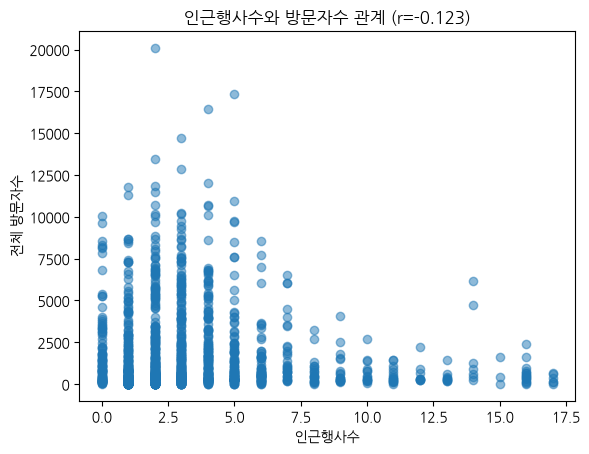

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='NanumGothic') # korean for plt
plt.rc('axes', unicode_minus=False) # prevent minus error

def analyze_correlation():
    df = pd.read_csv('Oworld_events.csv')

    correlation = df['인근행사수'].corr(df['전체건수'])

    print(f"인근행사수와 방문자수의 상관계수: {correlation:.3f}")

    if correlation >= 0.7:
        print("강한 양의 상관관계")
    elif correlation >= 0.3:
        print("중간 정도의 양의 상관관계")
    elif correlation > 0:
        print("약한 양의 상관관계")
    elif correlation <= -0.7:
        print("강한 음의 상관관계")
    elif correlation <= -0.3:
        print("중간 정도의 음의 상관관계")
    elif correlation < 0:
        print("약한 음의 상관관계")
    else:
        print("상관관계 없음")

    plt.scatter(df['인근행사수'], df['전체건수'], alpha=0.5)
    plt.xlabel('인근행사수')
    plt.ylabel('전체 방문자수')
    plt.title(f'인근행사수와 방문자수 관계 (r={correlation:.3f})')
    plt.show()


if __name__ == '__main__':
    analyze_correlation()

In [5]:
import pandas as pd

def merge_event_features():
    df = pd.read_csv('Oworld_wy.csv')
    ev = pd.read_csv('Oworld_events.csv', usecols=['일자', '인근행사수'])

    df['행사구분'] = df['행사구분'].map({
        '행사 없음': 0,
        '행사 있음': 1
    })

    df['일자'] = pd.to_datetime(df['일자'])
    ev['일자'] = pd.to_datetime(ev['일자'])

    df = df.merge(ev, on='일자', how='left')

    df['인근행사수'] = df['인근행사수'].fillna(0).astype(int)

    df.to_csv('Oworld_wy.csv', index=False, encoding='utf-8-sig')

    print(df[['일자', '행사구분', '인근행사수']].head(20))


if __name__ == '__main__':
    merge_event_features()

           일자  행사구분  인근행사수
0  2023-01-01     0      0
1  2023-01-02     0      0
2  2023-01-03     0      0
3  2023-01-04     0      0
4  2023-01-05     0      0
5  2023-01-06     0      2
6  2023-01-07     0      2
7  2023-01-08     0      2
8  2023-01-09     0      3
9  2023-01-10     0      2
10 2023-01-11     0      2
11 2023-01-12     0      2
12 2023-01-13     0      2
13 2023-01-14     0      2
14 2023-01-15     0      2
15 2023-01-16     0      2
16 2023-01-17     0      2
17 2023-01-18     0      2
18 2023-01-19     0      1
19 2023-01-20     0      1


사용할 Feature 추출

In [23]:
import pandas as pd


def create_oworld_files():
    df = pd.read_csv('Oworld_wy.csv')

    # Oworld.csv
    oworld = pd.DataFrame({
        'date': df['일자'], # 식별용

        'holiday': df['is_holiday'], # 데이터 신뢰도 검증 필요
        'weekend': df['주말여부'],

        'mon': df['요일_0'],
        'tue': df['요일_1'],
        'wed': df['요일_2'],
        'thur': df['요일_3'],
        'fri': df['요일_4'],
        'sat': df['요일_5'],
        'sun': df['요일_6'],

        'temperature': df['평균기온'],
        'rain': df['일강수량'],
        'humidity': df['평균상대습도'],
        'visitors': df['전체건수'], # target

    })

    # Oworld_hold.csv
    oworld_hold = pd.DataFrame({
        'date': df['일자'], # 식별용

        'dayoff': ((df['주말여부'] == 1) | (df['is_holiday'] == 1)).astype(int),

        # 아직 데이터 없음
        'sandwich': None,

        'jan': (df['월'] == 1).astype(int),
        'feb': (df['월'] == 2).astype(int),
        'mar': (df['월'] == 3).astype(int),
        'apr': (df['월'] == 4).astype(int),
        'may': (df['월'] == 5).astype(int),
        'jun': (df['월'] == 6).astype(int),
        'jul': (df['월'] == 7).astype(int),
        'aug': (df['월'] == 8).astype(int),
        'sep': (df['월'] == 9).astype(int),
        'oct': (df['월'] == 10).astype(int),
        'nov': (df['월'] == 11).astype(int),
        'dec': (df['월'] == 12).astype(int),

        'spring': df['계절_봄'],
        'summer': df['계절_여름'],
        'fall': df['계절_가을'],
        'winter': df['계절_겨울'],

        # 아직 데이터 없음
        'event': None
    })

    oworld.to_csv('Oworld_rain.csv', index=False, encoding='utf-8-sig')
    oworld_hold.to_csv('Oworld_hold.csv', index=False, encoding='utf-8-sig')


if __name__ == '__main__':
    create_oworld_files()

강수량 -> 강수확률로 변경

In [43]:
import pandas as pd

threshold = 1.0 # 1mm 이상

df = pd.read_csv('Oworld_rain.csv')
df['rain'] = (df['rain'] >= threshold).astype(float)
df.to_csv('Oworld_missing.csv', index=False, encoding='utf-8-sig')
print(f'처리 후 데이터 수: {len(df)}건')

처리 후 데이터 수: 1277건


결측치 확인

In [44]:
import pandas as pd
import datetime as dt

df.to_csv('Oworld_missing.csv', index=False, encoding='utf-8-sig')

# check_weather
columns = ['temperature', 'humidity']
for col in columns:
    count = (df[col] == 0).sum()
    print(f'{col}: {count}건')

# check_visitors
missing_dates = df.loc[df['visitors'] == 0, 'date'].tolist()
print(f'visitors 제거: {len(missing_dates)}건')
print(missing_dates)
df = df[df['visitors'] != 0]

df['date'] = pd.to_datetime(df['date'])
children = df.loc[((df['date'].dt.month == 5) & (df['date'].dt.day == 5)), 'date'].tolist()
print(f'어린이날 제거: {len(children)}건')
print(children)
df = df[~((df['date'].dt.month == 5) & (df['date'].dt.day == 5))]

df.to_csv('Oworld.csv', index=False, encoding='utf-8-sig')
print(f'처리 후 데이터 수: {len(df)}건')

temperature: 0건
humidity: 0건
visitors 제거: 57건
['2026-04-08', '2026-04-09', '2026-04-10', '2026-04-11', '2026-04-12', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24', '2026-04-25', '2026-04-26', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-02', '2026-05-03', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08', '2026-05-09', '2026-05-10', '2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22', '2026-05-23', '2026-05-24', '2026-05-25', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01', '2026-06-02', '2026-06-03']
어린이날 제거: 3건
[Timestamp('2023-05-05 00:00:00'), Timestamp('2024-05-05 00:00:00'), Timestamp('2025-05-05 00:00:00')]
처리 후 데이터 수: 1217건


In [ ]:
# holiday가 주말+공휴일로 되어있어 변경

df = pd.read_csv('Oworld.csv')
source = pd.read_csv('Oworld_final_processed.csv')

df['holiday'] = source['holiday']

df.to_csv('Oworld.csv', index=False, encoding='utf-8-sig')

0    1
1    0
2    0
3    0
4    0
Name: holiday, dtype: int64


In [53]:
# 공휴일 데이터 신뢰도 확인

df = pd.read_csv('Oworld.csv')

holidays = df[df['holiday'] == 1]

print(f'holiday == 1: {len(holidays)}건')
print(holidays['date'].tolist())

holiday == 1: 59건
['2023-01-01', '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-03-01', '2023-05-27', '2023-05-29', '2023-06-06', '2023-08-15', '2023-09-28', '2023-09-29', '2023-09-30', '2023-10-02', '2023-10-03', '2023-10-09', '2023-12-25', '2024-01-01', '2024-02-09', '2024-02-10', '2024-02-11', '2024-02-12', '2024-03-01', '2024-04-10', '2024-05-06', '2024-05-15', '2024-06-06', '2024-08-15', '2024-09-16', '2024-09-17', '2024-09-18', '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25', '2025-01-01', '2025-01-27', '2025-01-28', '2025-01-29', '2025-01-30', '2025-03-01', '2025-03-03', '2025-05-06', '2025-06-03', '2025-06-06', '2025-08-15', '2025-10-03', '2025-10-05', '2025-10-06', '2025-10-07', '2025-10-08', '2025-10-09', '2025-12-25', '2026-01-01', '2026-02-16', '2026-02-17', '2026-02-18', '2026-03-01', '2026-03-02']
